In [3]:
import numpy as np
from scipy.integrate import quad
from dataclasses import dataclass


def heston_semi_analytic(S0, K, T, r, V0, kappa, theta, omega, rho):
    """
    Heston (1993) semi-analytic European call option pricing formula.
    
    Computes the option price using numerical integration of the characteristic
    function under the Heston stochastic volatility model.
    
    Parameters
    ----------
    S0 : float
        Initial asset price.
    V0 : float
        Initial variance.
    r : float
        Risk-free interest rate.
    K : float
        Strike price.
    T : float
        Time to maturity (in years).
    kappa : float
        Mean-reversion speed of variance.
    theta : float
        Long-term mean of variance.
    omega : float
        Volatility of variance (vol of vol).
    rho : float
        Correlation between asset price and variance processes.
    
    Returns
    -------
    price : float
        European call option price.
    Notes
    -----
    The price is computed as: price = S0 * P1 - K * exp(-r * T) * P2,
    where P1 and P2 are the risk-neutral probabilities obtained via
    integration of the characteristic function.
    
    The integration is performed using SciPy's `quad` function over
    the range [1e-6, 200] with an absolute tolerance of 1e-6.

    Alec Wang

    """
    from scipy.integrate import quad

    def char_func(phi, S0, V0, r, T, kappa, theta, omega, rho, j):
        """Heston特征函数"""
        if j == 1:
            u = 0.5
            b = kappa - rho * omega
        else:
            u = -0.5
            b = kappa

        a   = kappa * theta
        x   = np.log(S0)
        d   = np.sqrt((rho*omega*phi*1j - b)**2 - omega**2*(2*u*phi*1j - phi**2))
        g   = (b - rho*omega*phi*1j + d) / (b - rho*omega*phi*1j - d)

        C_cf = (r*phi*1j*T +
                a/omega**2 * ((b - rho*omega*phi*1j + d)*T
                              - 2*np.log((1 - g*np.exp(d*T))/(1 - g))))
        D_cf = ((b - rho*omega*phi*1j + d)/omega**2 *
                (1 - np.exp(d*T)) / (1 - g*np.exp(d*T)))

        return np.exp(C_cf + D_cf*V0 + 1j*phi*x)

    def integrand_P(phi, S0, V0, r, K, T, kappa, theta, omega, rho, j):
        cf  = char_func(phi, S0, V0, r, T, kappa, theta, omega, rho, j)
        val = np.real(np.exp(-1j*phi*np.log(K)) * cf / (1j*phi))
        return val

    P1, _ = quad(integrand_P, 1e-6, 200, args=(S0,V0,r,K,T,kappa,theta,omega,rho,1),
                 limit=200, epsabs=1e-6)
    P2, _ = quad(integrand_P, 1e-6, 200, args=(S0,V0,r,K,T,kappa,theta,omega,rho,2),
                 limit=200, epsabs=1e-6)

    P1 = 0.5 + P1/np.pi
    P2 = 0.5 + P2/np.pi

    price = S0*P1 - K*np.exp(-r*T)*P2
    return price

The characteristic-function implementation produces
a European call option value together with the
risk-neutral probabilities P1 and P2.

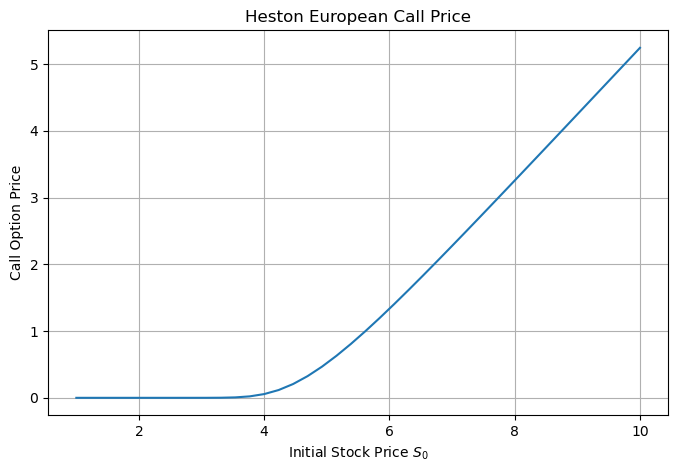

In [6]:
import matplotlib.pyplot as plt

S_values = np.linspace(1,10,40)

prices = []

for S in S_values:

    price = heston_semi_analytic(
        S0=S,
        K=5,
        T=1,
        r=0.05,
        V0=0.04,
        kappa=2.0,
        theta=0.04,
        omega=0.3,
        rho=-0.7
    )

    prices.append(price)

plt.figure(figsize=(8,5))

plt.plot(S_values, prices)

plt.xlabel("Initial Stock Price $S_0$")
plt.ylabel("Call Option Price")

plt.title("Heston European Call Price")

plt.grid(True)

plt.show()

In [8]:
def heston_mc_european_call(S0, K, T, r, kappa, theta, omega, rho, V0, n_steps, n_sims):
    """
    Prices a European Call option under the Heston Stochastic Volatility Model 
    using a vectorized Euler-Maruyama Monte Carlo simulation.

    return (call_price, standard_error)

    Justin(Yue) Ju
    """
    dt = T/n_steps
    S = np.zeros(n_sims) + S0
    V = np.zeros(n_sims) + V0
    sqrt_dt = np.sqrt(dt)
    sqrt_1_minus_rho2 = np.sqrt(1 - rho**2)

    for i in range(n_steps):
        Z_t = np.random.standard_normal(n_sims)
        Z_t_tilde = np.random.standard_normal(n_sims)
        
        W_S = Z_t
        W_V = rho * Z_t + sqrt_1_minus_rho2 * Z_t_tilde
        
        V_max = np.maximum(V, 0.0)
        
        S = S + r * S * dt + np.sqrt(V_max) * S * sqrt_dt * W_S
        V = V + kappa * (theta - V_max) * dt + omega * np.sqrt(V_max) * sqrt_dt * W_V

    payoffs = np.maximum(S - K, 0)
    discount_factor = np.exp(-r*T)
    call_price = discount_factor * np.mean(payoffs)
    standard_error = np.std(payoffs * discount_factor) / np.sqrt(n_sims)

    return call_price, standard_error

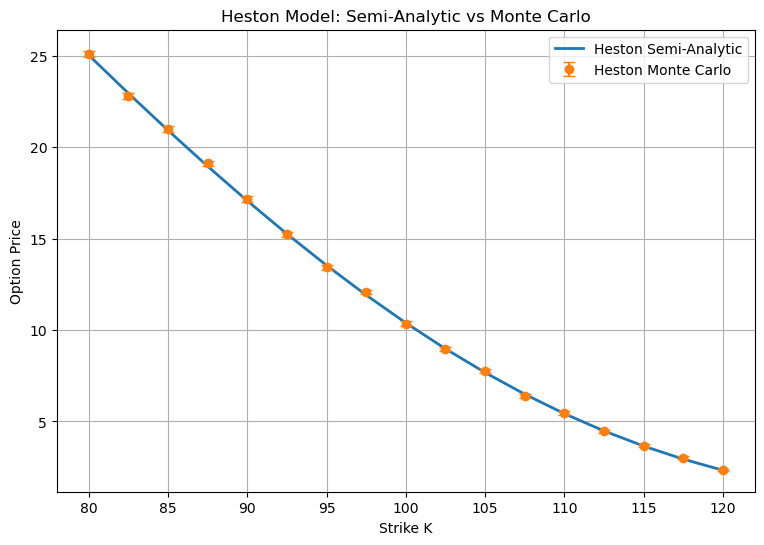

In [10]:
import numpy as np
import matplotlib.pyplot as plt

S0 = 100
T = 1.0
r = 0.05
V0 = 0.04
kappa = 2.0
theta = 0.04
omega = 0.3
rho = -0.7

n_steps = 1000
n_sims = 10000

K_list = np.linspace(80, 120, 17)

semi_prices = []
mc_prices = []
mc_errors = []

for K in K_list:
    p_semi = heston_semi_analytic(S0, K, T, r, V0, kappa, theta, omega, rho)
    semi_prices.append(p_semi)

    p_mc, se_mc = heston_mc_european_call(
        S0, K, T, r, kappa, theta, omega, rho, V0, n_steps, n_sims
    )
    mc_prices.append(p_mc)
    mc_errors.append(se_mc)

semi_prices = np.array(semi_prices)
mc_prices = np.array(mc_prices)
mc_errors = np.array(mc_errors)

plt.figure(figsize=(9, 6))
plt.plot(K_list, semi_prices, label='Heston Semi-Analytic', linewidth=2)
plt.errorbar(K_list, mc_prices, yerr=mc_errors, fmt='o', capsize=4, label='Heston Monte Carlo')

plt.xlabel('Strike K')
plt.ylabel('Option Price')
plt.title('Heston Model: Semi-Analytic vs Monte Carlo')
plt.legend()
plt.grid(True)
plt.show()

### Discussion

As the strike price increases, the value of the European call option decreases. A larger strike makes it less likely that the option will finish in-the-money at maturity.

The Monte Carlo estimates are very close to the semi-analytic Heston prices. Small differences arise from simulation error and remain within the confidence intervals.

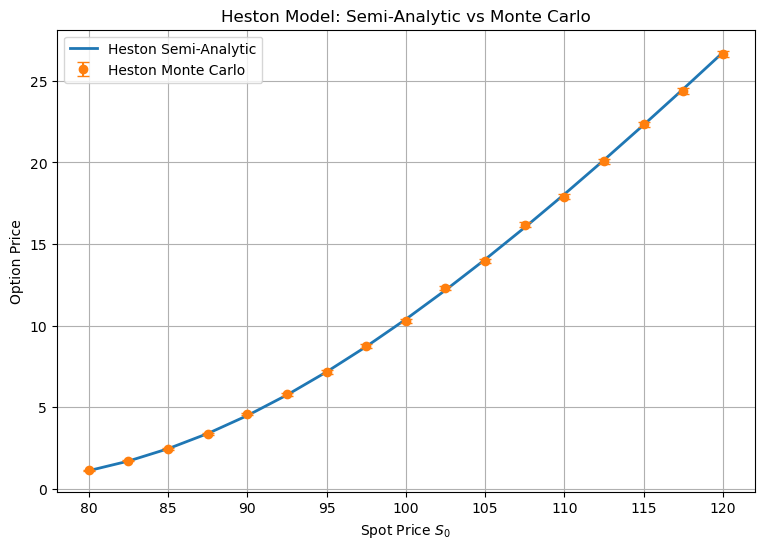

In [12]:
import numpy as np
import matplotlib.pyplot as plt

K = 100
T = 1.0
r = 0.05
V0 = 0.04
kappa = 2.0
theta = 0.04
omega = 0.3
rho = -0.7

n_steps = 1000
n_sims = 10000

S0_list = np.linspace(80, 120, 17)

semi_prices = []
mc_prices = []
mc_errors = []

for S0 in S0_list:
    p_semi = heston_semi_analytic(S0, K, T, r, V0, kappa, theta, omega, rho)
    semi_prices.append(p_semi)

    p_mc, se_mc = heston_mc_european_call(S0, K, T, r, kappa, theta, omega, rho, V0, n_steps, n_sims)
    mc_prices.append(p_mc)
    mc_errors.append(se_mc)

semi_prices = np.array(semi_prices)
mc_prices = np.array(mc_prices)
mc_errors = np.array(mc_errors)

plt.figure(figsize=(9, 6))
plt.plot(S0_list, semi_prices, label='Heston Semi-Analytic', linewidth=2)
plt.errorbar(S0_list, mc_prices, yerr=mc_errors, fmt='o', capsize=4, label='Heston Monte Carlo')

plt.xlabel('Spot Price $S_0$')
plt.ylabel('Option Price')
plt.title('Heston Model: Semi-Analytic vs Monte Carlo')
plt.legend()
plt.grid(True)
plt.show()

### Discussion

As the initial stock price increases, the call option value increases. This behaviour is consistent with financial intuition, since a higher stock price increases the probability of exercising the option profitably.

The Monte Carlo method produces results that closely match the semi-analytic benchmark, providing validation of both implementations.

# Appendix: Characteristic Function Approach

## Characteristic Function

Under the Heston model, the stock price and variance satisfy

$$
dS_t=rS_tdt+\sqrt{V_t}S_tdW_t^S
$$

and

$$
dV_t=\kappa(\theta-V_t)dt+\sigma\sqrt{V_t}dW_t^V,
$$

with correlation

$$
dW_t^SdW_t^V=\rho dt.
$$

Unlike the Black-Scholes model, the distribution of the terminal stock price is not lognormal. Therefore, pricing is based on the characteristic function of the log-price

$$
\phi(u)=\mathbb E[e^{iuX_T}],
$$

where

$$
X_T=\ln(S_T).
$$

## Fourier Inversion

The risk-neutral probabilities are computed through Fourier inversion,

$$
P_j
=
\frac12
+
\frac1\pi
\int_0^\infty
\Re
\left[
\frac{
e^{-iu\ln K}\phi_j(u)
}{
iu
}
\right]
du,
\qquad j=1,2.
$$

The corresponding European call price is

$$
C=S_0P_1-Ke^{-rT}P_2.
$$

## Correspondence with the Implementation

| Mathematical quantity | Implementation |
|----------------------|----------------|
| Characteristic function | `char_func()` |
| Fourier inversion | `quad()` |
| Semi-analytic pricing | `heston_semi_analytic()` |
| Monte Carlo benchmark | `heston_mc_european_call()` |

The semi-analytic formula is used as the benchmark, while Monte Carlo simulation provides an independent numerical approximation. The close agreement observed in the numerical experiments supports the correctness of the implementation.